# Étape 7 — Embeddings sémantiques CV–Job et similarité cosinus

Ce notebook applique uniquement la première méthode de prédiction de liens : transformer les textes
des CV et Jobs en embeddings communs, calculer une similarité cosinus sur les paires fixes de
l'Étape 6, puis évaluer ce score. Aucun score structurel, enrichissement ou modèle supervisé n'est
utilisé.

## 1. Données et split expérimental inchangé

Nous rechargeons les tables `resumes` et `jobs` avec la logique validée à l'Étape 1. Les trois CSV
de l'Étape 6 sont chargés tels quels : nous ne recréons, ne rééquilibrons et ne mélangeons aucun
split. **Train** contient les exemples disponibles pour un éventuel apprentissage futur,
**validation** sert uniquement aux choix méthodologiques (ici le seuil), et **test** reste réservé à
l'évaluation finale. Utiliser les mêmes paires est indispensable pour comparer plus tard les
méthodes sémantiques, structurelles et hybrides.

In [1]:
from pathlib import Path
import json
import os
import time

# Le projet utilise SentenceTransformers avec PyTorch. Cette variable empêche Transformers
# d'importer inutilement TensorFlow lorsqu'il est présent dans l'environnement.
os.environ["USE_TF"] = "0"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

DATASET_ID = "michaelozon/candidate-matching-synthetic"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
NORMALIZE_EMBEDDINGS = True
BATCH_SIZE = 64
ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures" / "step7"
for directory in (PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

df_resumes = load_dataset(DATASET_ID, data_dir="resumes", split="train").to_pandas()
df_jobs = load_dataset(DATASET_ID, data_dir="jobs", split="train").to_pandas()
train_pairs = pd.read_csv(RESULTS_DIR / "step6_link_train_pairs.csv")
val_pairs = pd.read_csv(RESULTS_DIR / "step6_link_val_pairs.csv")
test_pairs = pd.read_csv(RESULTS_DIR / "step6_link_test_pairs.csv")

def verify_split(frame, n_rows, n_per_class):
    assert len(frame) == n_rows
    assert frame.columns.tolist() == ["resume_id", "job_id", "label"]
    assert frame["label"].value_counts().to_dict() == {0: n_per_class, 1: n_per_class}
    assert not frame.duplicated(["resume_id", "job_id"]).any()

assert len(df_resumes) == 10_000
assert len(df_jobs) == 2_500
verify_split(train_pairs, 120_000, 60_000)
verify_split(val_pairs, 15_000, 7_500)
verify_split(test_pairs, 15_000, 7_500)

display(pd.DataFrame({
    "table": ["resumes", "jobs", "train", "validation", "test"],
    "rows": [len(df_resumes), len(df_jobs), len(train_pairs), len(val_pairs), len(test_pairs)],
}))

,table,rows
0,resumes,10000
1,jobs,2500
2,train,120000
3,validation,15000
4,test,15000


## 2. Du texte vers un embedding

Un **embedding** est un vecteur numérique de dimension fixe qui représente le contenu d'un texte.
Transformer les textes en vecteurs permet d'utiliser des opérations mathématiques pour comparer
leur sens général. Deux textes sémantiquement proches devraient avoir des vecteurs proches.

CV et Jobs doivent absolument être encodés par **le même modèle et dans le même espace vectoriel**.
Sinon, une coordonnée du vecteur CV n'aurait pas la même signification qu'une coordonnée du vecteur
Job et leur comparaison serait incohérente.

Les IDs ne sont jamais inclus : ils identifient une ligne mais ne portent aucun sens professionnel.

## 3. Construction du texte d'un CV

Un CV ne se résume pas à son rôle. Nous concaténons les attributs disponibles avec des préfixes
explicites : rôle, séniorité, années d'expérience, industrie, diplôme, compétences, résumé et
expériences. Ces préfixes aident le modèle à distinguer la fonction de chaque fragment. Les listes
sont jointes lisiblement, les champs absents sont ignorés et aucune information inexistante n'est
inventée.

In [2]:
RESUME_TEXT_FIELDS = [
    "role", "seniority", "years_experience", "industry", "education",
    "skills", "summary", "experience_bullets",
]

def text_value(value):
    if value is None or (not isinstance(value, (list, tuple, np.ndarray)) and pd.isna(value)):
        return ""
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        return "; ".join(str(item) for item in value if str(item).strip())
    return str(value).strip()

def build_resume_text(row):
    labeled_fields = [
        ("Role", "role"),
        ("Seniority", "seniority"),
        ("Years of experience", "years_experience"),
        ("Industry", "industry"),
        ("Education", "education"),
        ("Skills", "skills"),
        ("Summary", "summary"),
        ("Experience", "experience_bullets"),
    ]
    parts = []
    for label, field in labeled_fields:
        value = text_value(row.get(field))
        if value:
            parts.append(f"{label}: {value}")
    return "\n".join(parts)

df_resumes = df_resumes.copy()
df_resumes["semantic_text"] = df_resumes.apply(build_resume_text, axis=1)
for text in df_resumes["semantic_text"].head(3):
    print(text)
    print("-" * 100)

Role: Software Engineer
Seniority: Senior
Years of experience: 12
Industry: EdTech
Education: BSc
Skills: OOP; Databases; Git; Docker; Python; Unit Testing; Java
Summary: Software Engineer with 12 years of experience in EdTech.
Experience: Delivered results using structured workflows and clear communication; Collaborated with stakeholders to define needs and execute tasks; Maintained reporting and documentation to support team performance
----------------------------------------------------------------------------------------------------
Role: Marketing Manager
Seniority: Junior
Years of experience: 2
Industry: E-commerce
Education: BSc
Skills: Content Marketing; Meta Ads; Conversion Optimization; SEO; Landing Pages
Summary: Marketing Manager with 2 years of experience in E-commerce.
Experience: Delivered results using structured workflows and clear communication; Collaborated with stakeholders to define needs and execute tasks; Maintained reporting and documentation to support team pe

## 4. Construction du texte d'un Job

Pour un Job, nous concaténons titre, séniorité, industrie, compétences obligatoires et souhaitées,
description, responsabilités et exigences. Les mêmes principes s'appliquent : préfixes explicites,
aucun ID et aucune donnée inventée. Le texte Job diffère naturellement du texte CV, mais les deux
seront encodés par le même modèle.

In [3]:
JOB_TEXT_FIELDS = [
    "job_title", "seniority", "industry", "must_have_skills",
    "nice_to_have_skills", "description", "responsibilities", "requirements",
]

def build_job_text(row):
    labeled_fields = [
        ("Job title", "job_title"),
        ("Seniority", "seniority"),
        ("Industry", "industry"),
        ("Must-have skills", "must_have_skills"),
        ("Nice-to-have skills", "nice_to_have_skills"),
        ("Description", "description"),
        ("Responsibilities", "responsibilities"),
        ("Requirements", "requirements"),
    ]
    parts = []
    for label, field in labeled_fields:
        value = text_value(row.get(field))
        if value:
            parts.append(f"{label}: {value}")
    return "\n".join(parts)

df_jobs = df_jobs.copy()
df_jobs["semantic_text"] = df_jobs.apply(build_job_text, axis=1)
for text in df_jobs["semantic_text"].head(3):
    print(text)
    print("-" * 100)

Job title: Project Manager
Seniority: Senior
Industry: Retail
Must-have skills: Timeline Management; Process Improvement; Stakeholder Communication
Nice-to-have skills: Asana
Description: We are hiring a Project Manager to support teams in Retail.
Responsibilities: Deliver high-quality work aligned with goals and timelines; Collaborate with stakeholders and communicate progress clearly; Improve processes and contribute to measurable outcomes
Requirements: Relevant experience and ability to learn quickly; Strong communication and ownership mindset; Comfort working with tools, data, and cross-functional teams
----------------------------------------------------------------------------------------------------
Job title: Customer Success Associate
Seniority: Senior
Industry: EdTech
Must-have skills: Troubleshooting; Customer Satisfaction; Intercom
Nice-to-have skills: Root Cause Analysis
Description: We are hiring a Customer Success Associate to support teams in EdTech.
Responsibilities: D

## 5. Choix du modèle d'embedding

 Nous choisissons `sentence-transformers/all-MiniLM-L6-v2`, un SentenceTransformer pré-entraîné compact qui encode
phrases et paragraphes dans un espace commun de 384 dimensions. 

In [4]:
try:
    embedding_model = SentenceTransformer(MODEL_NAME)
except Exception as error:
    raise RuntimeError(
        "Impossible de charger sentence-transformers/all-MiniLM-L6-v2. "
        "Vérifier l'installation de sentence-transformers et l'accès à Hugging Face."
    ) from error

print("Modèle chargé :", MODEL_NAME)
print("Device utilisé :", embedding_model.device)

Modèle chargé : sentence-transformers/all-MiniLM-L6-v2
Device utilisé : cuda:0


## 6. Génération et sauvegarde des embeddings

Nous encodons chaque texte exactement une fois, par lots de 64 pour limiter la mémoire. Avec
`normalize_embeddings=True`, chaque vecteur reçoit une norme euclidienne L2 égale à 1. Nous
mesurons séparément les temps CV et Jobs, vérifions shapes, types, valeurs finies et normes, puis
sauvegardons les matrices `.npy` ainsi que le mapping déterministe `ID → ligne`.

In [5]:
resume_start = time.perf_counter()
resume_embeddings = embedding_model.encode(
    df_resumes["semantic_text"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
)
resume_encoding_seconds = time.perf_counter() - resume_start

job_start = time.perf_counter()
job_embeddings = embedding_model.encode(
    df_jobs["semantic_text"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=NORMALIZE_EMBEDDINGS,
)
job_encoding_seconds = time.perf_counter() - job_start
total_encoding_seconds = resume_encoding_seconds + job_encoding_seconds

embedding_dimension = int(resume_embeddings.shape[1])
assert resume_embeddings.shape == (10_000, embedding_dimension)
assert job_embeddings.shape == (2_500, embedding_dimension)
assert resume_embeddings.dtype == job_embeddings.dtype
assert np.isfinite(resume_embeddings).all()
assert np.isfinite(job_embeddings).all()
if NORMALIZE_EMBEDDINGS:
    assert np.allclose(np.linalg.norm(resume_embeddings, axis=1), 1, atol=1e-5)
    assert np.allclose(np.linalg.norm(job_embeddings, axis=1), 1, atol=1e-5)

print("Embeddings CV :", resume_embeddings.shape, resume_embeddings.dtype)
print("Embeddings Jobs :", job_embeddings.shape, job_embeddings.dtype)
print(f"Temps CV : {resume_encoding_seconds:.2f} s")
print(f"Temps Jobs : {job_encoding_seconds:.2f} s")
print(f"Temps total : {total_encoding_seconds:.2f} s")

np.save(PROCESSED_DIR / "resume_embeddings.npy", resume_embeddings)
np.save(PROCESSED_DIR / "job_embeddings.npy", job_embeddings)

resume_id_map = pd.DataFrame({
    "resume_id": df_resumes["resume_id"],
    "embedding_row": np.arange(len(df_resumes)),
})
job_id_map = pd.DataFrame({
    "job_id": df_jobs["job_id"],
    "embedding_row": np.arange(len(df_jobs)),
})
resume_id_map.to_csv(PROCESSED_DIR / "resume_embedding_ids.csv", index=False)
job_id_map.to_csv(PROCESSED_DIR / "job_embedding_ids.csv", index=False)

embedding_metadata = {
    "model_name": MODEL_NAME,
    "embedding_dimension": embedding_dimension,
    "n_resumes": int(len(df_resumes)),
    "n_jobs": int(len(df_jobs)),
    "normalize_embeddings": NORMALIZE_EMBEDDINGS,
    "batch_size": BATCH_SIZE,
    "resume_text_fields": RESUME_TEXT_FIELDS,
    "job_text_fields": JOB_TEXT_FIELDS,
    "resume_encoding_seconds": float(resume_encoding_seconds),
    "job_encoding_seconds": float(job_encoding_seconds),
    "total_encoding_seconds": float(total_encoding_seconds),
    "dtype": str(resume_embeddings.dtype),
}
(RESULTS_DIR / "step7_embedding_metadata.json").write_text(
    json.dumps(embedding_metadata, indent=2, ensure_ascii=False), encoding="utf-8"
)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embeddings CV : (10000, 384) float32
Embeddings Jobs : (2500, 384) float32
Temps CV : 22.82 s
Temps Jobs : 6.80 s
Temps total : 29.62 s


707

## 9. Scores vectorisés des seules paires du benchmark

Nous construisons deux dictionnaires `ID → ligne`, récupérons simultanément les lignes d'embeddings
de toutes les paires, puis effectuons un produit élément par élément suivi d'une somme par ligne.
Cette opération vectorisée calcule exactement le produit scalaire de chaque couple. Nous ne créons
pas la matrice dense de 25 millions de paires, inutile pour ce benchmark fixe.

In [6]:
resume_to_row = dict(zip(resume_id_map["resume_id"], resume_id_map["embedding_row"]))
job_to_row = dict(zip(job_id_map["job_id"], job_id_map["embedding_row"]))

def add_semantic_score(pair_frame):
    result = pair_frame.copy()
    resume_rows = result["resume_id"].map(resume_to_row)
    job_rows = result["job_id"].map(job_to_row)
    if resume_rows.isna().any() or job_rows.isna().any():
        raise KeyError("Au moins un ID du benchmark n'a pas d'embedding.")
    resume_vectors = resume_embeddings[resume_rows.to_numpy(dtype=int)]
    job_vectors = job_embeddings[job_rows.to_numpy(dtype=int)]
    result["semantic_score"] = np.einsum("ij,ij->i", resume_vectors, job_vectors)
    assert np.isfinite(result["semantic_score"]).all()
    return result

semantic_train = add_semantic_score(train_pairs)
semantic_val = add_semantic_score(val_pairs)
semantic_test = add_semantic_score(test_pairs)

semantic_train.to_csv(RESULTS_DIR / "step7_semantic_train_scores.csv", index=False)
semantic_val.to_csv(RESULTS_DIR / "step7_semantic_val_scores.csv", index=False)
semantic_test.to_csv(RESULTS_DIR / "step7_semantic_test_scores.csv", index=False)

display(semantic_test.head())

,resume_id,job_id,label,semantic_score
0,R_005333,J_000010,0,0.393031
1,R_008660,J_000363,1,0.435588
2,R_007540,J_000874,0,0.478570
3,R_001108,J_001968,1,0.712785
4,R_007989,J_000869,1,0.606714


## 10. Distribution des scores

Une méthode informative doit attribuer, **statistiquement**, des scores plus élevés aux vrais
matches qu'aux négatifs. Cela n'exige pas une séparation parfaite : des distributions peuvent se
chevaucher. Nous décrivons moyenne, médiane, écart-type, extrêmes et quantiles par label, puis
comparons graphiquement validation et test sans modifier le modèle.

Validation


,count,mean,median,std,min,q05,q25,q75,q95,max
label,,,,,,,,,,
0,7500,0.505404,0.489147,0.091639,0.287606,0.384839,0.442666,0.549831,0.689030,0.905512
1,7500,0.652032,0.653987,0.097160,0.345286,0.484359,0.588900,0.718952,0.805705,0.912622


Test


,count,mean,median,std,min,q05,q25,q75,q95,max
label,,,,,,,,,,
0,7500,0.501914,0.484466,0.090849,0.262236,0.385203,0.440899,0.543996,0.683566,0.912213
1,7500,0.650874,0.651579,0.097521,0.335188,0.483988,0.585145,0.720517,0.805935,0.916283


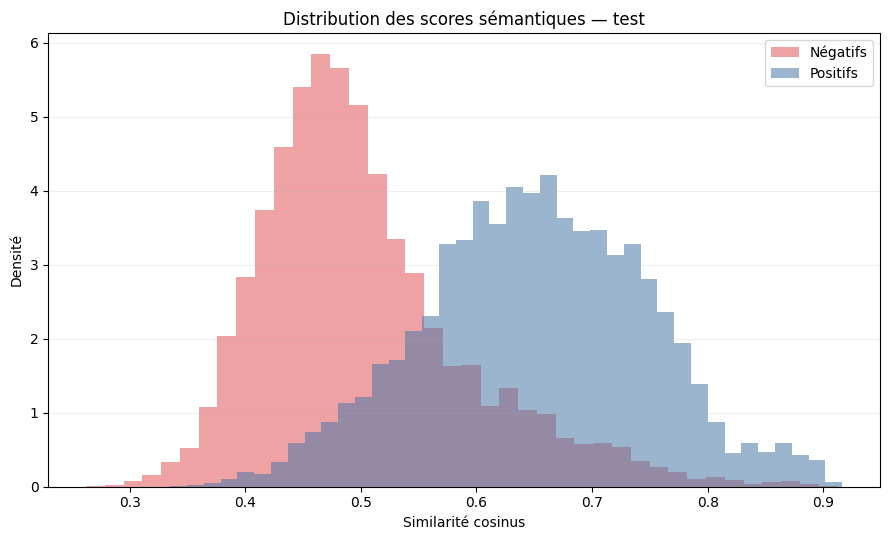

In [7]:
def score_statistics(frame):
    rows = []
    for label, group in frame.groupby("label"):
        score = group["semantic_score"]
        rows.append({
            "label": int(label),
            "count": int(len(score)),
            "mean": float(score.mean()),
            "median": float(score.median()),
            "std": float(score.std()),
            "min": float(score.min()),
            "q05": float(score.quantile(0.05)),
            "q25": float(score.quantile(0.25)),
            "q75": float(score.quantile(0.75)),
            "q95": float(score.quantile(0.95)),
            "max": float(score.max()),
        })
    return pd.DataFrame(rows).set_index("label")

val_score_stats = score_statistics(semantic_val)
test_score_stats = score_statistics(semantic_test)
print("Validation")
display(val_score_stats)
print("Test")
display(test_score_stats)

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, color, name in [(0, "#E15759", "Négatifs"), (1, "#4C78A8", "Positifs")]:
    ax.hist(
        semantic_test.loc[semantic_test["label"] == label, "semantic_score"],
        bins=40, density=True, alpha=0.55, color=color, label=name,
    )
ax.set(title="Distribution des scores sémantiques — test", xlabel="Similarité cosinus", ylabel="Densité")
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "semantic_score_distribution_test.png", dpi=170, bbox_inches="tight")
plt.show()

## 11. ROC-AUC

La courbe ROC fait varier le seuil et compare le taux de vrais positifs au taux de faux positifs.
La **ROC-AUC** est l'aire sous cette courbe. Elle peut s'interpréter comme la probabilité qu'un
positif choisi au hasard reçoive un score supérieur à un négatif choisi au hasard. Une valeur de
0,5 correspond à un classement aléatoire ; 1 indique un classement parfait. Le test est seulement
mesuré, jamais utilisé pour choisir un paramètre.

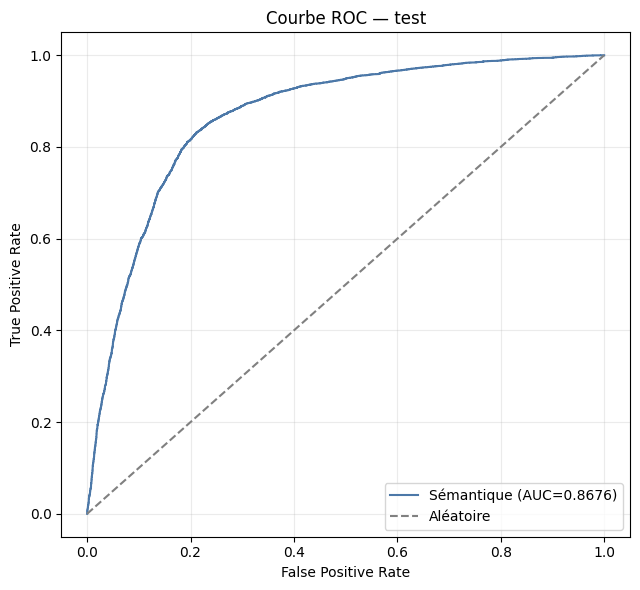

,ROC-AUC
train,0.863079
validation,0.862292
test,0.867627


In [8]:
train_roc_auc = roc_auc_score(semantic_train["label"], semantic_train["semantic_score"])
val_roc_auc = roc_auc_score(semantic_val["label"], semantic_val["semantic_score"])
test_roc_auc = roc_auc_score(semantic_test["label"], semantic_test["semantic_score"])

fpr_test, tpr_test, _ = roc_curve(semantic_test["label"], semantic_test["semantic_score"])
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr_test, tpr_test, color="#4C78A8", label=f"Sémantique (AUC={test_roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Aléatoire")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="Courbe ROC — test")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "semantic_roc_test.png", dpi=170, bbox_inches="tight")
plt.show()

display(pd.Series({"train": train_roc_auc, "validation": val_roc_auc, "test": test_roc_auc}, name="ROC-AUC").to_frame())

## 12. Average Precision / PR-AUC

La courbe précision-rappel se concentre sur la qualité des prédictions positives et devient
particulièrement utile lorsque les classes sont rares. `average_precision_score` résume cette
courbe. Notre benchmark est volontairement équilibré à 50/50 par downsampling, alors que l'espace
naturel contient seulement 0,3 % de positifs : l'Average Precision mesurée ici ne reproduit donc
pas directement la performance d'un système déployé sur toutes les paires possibles.

In [9]:
train_average_precision = average_precision_score(semantic_train["label"], semantic_train["semantic_score"])
val_average_precision = average_precision_score(semantic_val["label"], semantic_val["semantic_score"])
test_average_precision = average_precision_score(semantic_test["label"], semantic_test["semantic_score"])
display(pd.Series({
    "train": train_average_precision,
    "validation": val_average_precision,
    "test": test_average_precision,
}, name="Average Precision").to_frame())

,Average Precision
train,0.833105
validation,0.836278
test,0.840386


## 13. Choix du seuil exclusivement sur validation

Pour convertir un score continu en `match prédit` ou `non-match prédit`, il faut un seuil. Precision
mesure la proportion de prédictions positives correctes ; Recall la proportion de vrais positifs
retrouvés ; et leur moyenne harmonique est

$$F1=2\frac{Precision\times Recall}{Precision+Recall}.$$

Nous testons 1 001 seuils régulièrement espacés entre les scores minimum et maximum de
**validation**, puis retenons celui qui maximise le F1 validation. En cas d'égalité, le premier seuil
maximal est gardé de façon déterministe. Le test n'intervient jamais dans ce choix.

In [10]:
threshold_grid = np.linspace(
    semantic_val["semantic_score"].min(),
    semantic_val["semantic_score"].max(),
    1001,
)
y_val = semantic_val["label"].to_numpy()
val_scores = semantic_val["semantic_score"].to_numpy()
threshold_rows = []

for threshold in threshold_grid:
    prediction = (val_scores >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "precision": float(precision_score(y_val, prediction, zero_division=0)),
        "recall": float(recall_score(y_val, prediction, zero_division=0)),
        "f1": float(f1_score(y_val, prediction, zero_division=0)),
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.iloc[threshold_results["f1"].to_numpy().argmax()]
best_threshold = float(best_threshold_row["threshold"])
val_prediction = (val_scores >= best_threshold).astype(int)
val_precision = precision_score(y_val, val_prediction)
val_recall = recall_score(y_val, val_prediction)
val_f1 = f1_score(y_val, val_prediction)
val_confusion = confusion_matrix(y_val, val_prediction)

display(pd.Series({
    "best_threshold": best_threshold,
    "precision": val_precision,
    "recall": val_recall,
    "f1": val_f1,
}, name="validation").to_frame())
print("Matrice de confusion validation :\n", val_confusion)

,validation
best_threshold,0.548863
precision,0.771132
recall,0.852667
f1,0.809852


Matrice de confusion validation :
 [[5602 1898]
 [1105 6395]]


## 14. Évaluation finale sur test avec le seuil gelé

Le seuil choisi sur validation est maintenant gelé et appliqué une seule fois au test. ROC-AUC et
Average Precision évaluent le classement continu ; Precision, Recall, F1 et accuracy évaluent la
décision binaire au seuil fixé. L'accuracy est secondaire, car elle peut devenir trompeuse en cas de
fort déséquilibre. Aucune optimisation n'est effectuée après observation de ces résultats.

,test
ROC-AUC,0.867627
Average Precision,0.840386
threshold_from_validation,0.548863
precision,0.784835
recall,0.850133
f1,0.816180
accuracy,0.808533


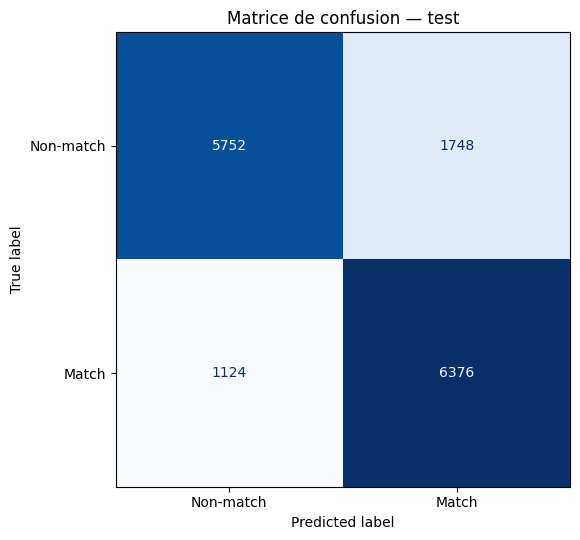

In [11]:
y_test = semantic_test["label"].to_numpy()
test_scores = semantic_test["semantic_score"].to_numpy()
test_prediction = (test_scores >= best_threshold).astype(int)

test_precision = precision_score(y_test, test_prediction)
test_recall = recall_score(y_test, test_prediction)
test_f1 = f1_score(y_test, test_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_confusion = confusion_matrix(y_test, test_prediction)

display(pd.Series({
    "ROC-AUC": test_roc_auc,
    "Average Precision": test_average_precision,
    "threshold_from_validation": best_threshold,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "accuracy": test_accuracy,
}, name="test").to_frame())

fig, ax = plt.subplots(figsize=(6.2, 5.5))
ConfusionMatrixDisplay(test_confusion, display_labels=["Non-match", "Match"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Matrice de confusion — test")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "semantic_confusion_matrix_test.png", dpi=170, bbox_inches="tight")
plt.show()

## 15. Exemples interprétables du test

Nous examinons trois groupes sans modifier le modèle : positifs les mieux scorés, positifs les moins
bien scorés et négatifs les mieux scorés. Les derniers sont des non-matches selon la vérité terrain,
mais peuvent être sémantiquement plausibles. Les attributs permettent d'identifier les signaux
probables — rôles, industries ou compétences — et les limites du score.

In [12]:
resume_info = df_resumes.set_index("resume_id")[["role", "seniority", "industry", "skills"]]
job_info = df_jobs.set_index("job_id")[["job_title", "seniority", "industry", "must_have_skills"]]

def enrich_examples(frame):
    result = frame[["resume_id", "job_id", "label", "semantic_score"]].copy()
    result = result.join(resume_info, on="resume_id", rsuffix="_cv")
    result = result.rename(columns={
        "role": "cv_role", "seniority": "cv_seniority",
        "industry": "cv_industry", "skills": "cv_skills",
    })
    result = result.join(job_info, on="job_id", rsuffix="_job")
    result = result.rename(columns={
        "job_title": "job_title", "seniority": "job_seniority",
        "industry": "job_industry", "must_have_skills": "job_must_have_skills",
    })
    return result

positive_test = semantic_test[semantic_test["label"] == 1]
negative_test = semantic_test[semantic_test["label"] == 0]

print("10 positifs test aux scores les plus élevés")
display(enrich_examples(positive_test.nlargest(10, "semantic_score")))
print("10 positifs test aux scores les plus faibles")
display(enrich_examples(positive_test.nsmallest(10, "semantic_score")))
print("10 négatifs test aux scores les plus élevés")
display(enrich_examples(negative_test.nlargest(10, "semantic_score")))

10 positifs test aux scores les plus élevés


,resume_id,job_id,label,semantic_score,cv_role,cv_seniority,cv_industry,cv_skills,job_title,job_seniority,job_industry,job_must_have_skills
10664,R_004383,J_002381,1,0.916283,Junior Accountant,Senior,Cybersecurity,"[Cash Flow, Excel, KPIs, Budgeting, Variance A...",Junior Accountant,Mid,Cybersecurity,"[Accounting, Cash Flow, Excel, Financial Model..."
13871,R_005896,J_001170,1,0.910137,Technical Support Specialist,Junior,Retail,"[Communication, Escalations, SLA, Zendesk, Int...",Technical Support Specialist,Senior,Retail,"[Intercom, Customer Satisfaction, SLA, Zendesk..."
2449,R_004058,J_001013,1,0.908962,Junior Accountant,Junior,SaaS,"[KPIs, Valuation, Reporting, Accounting, Finan...",Junior Accountant,Senior,SaaS,"[Valuation, Reporting, Excel, Budgeting, Varia..."
2106,R_002182,J_001271,1,0.907578,Operations Manager,Senior,FinTech,"[Project Planning, Jira, Risk Management, Repo...",Operations Manager,Junior,FinTech,"[Risk Management, Cross-functional Coordinatio..."
10130,R_003759,J_000647,1,0.905642,Junior Accountant,Mid,SaaS,"[Budgeting, KPIs, Valuation, Cash Flow, Accoun...",Junior Accountant,Junior,SaaS,"[Cash Flow, Forecasting, KPIs, Valuation]"
7104,R_005265,J_000533,1,0.904831,Junior Accountant,Junior,SaaS,"[Variance Analysis, Budgeting, Forecasting, Ac...",Junior Accountant,Senior,SaaS,"[Excel, Cash Flow, Budgeting, Forecasting, KPIs]"
8480,R_002340,J_001219,1,0.902575,Customer Success Associate,Senior,FinTech,"[Ticketing, Root Cause Analysis, Documentation...",Customer Success Associate,Senior,FinTech,"[Ticketing, Intercom, Zendesk, Escalations, Co..."
4762,R_005789,J_000102,1,0.899015,FP&A Analyst,Junior,FinTech,"[KPIs, Excel, Budgeting, Financial Modeling, V...",FP&A Analyst,Junior,FinTech,"[Accounting, Excel, Cash Flow, Financial Model..."
4449,R_006202,J_000041,1,0.897997,Associate Product Manager,Junior,FinTech,"[Agile, User Research, Product Strategy, Stake...",Associate Product Manager,Junior,FinTech,"[PRD, Analytics, Prioritization, User Research..."
8575,R_006236,J_002252,1,0.897632,Associate Product Manager,Mid,Cybersecurity,"[User Research, Product Strategy, Prioritizati...",Associate Product Manager,Mid,Cybersecurity,"[Stakeholder Management, Scrum, PRD]"


10 positifs test aux scores les plus faibles


,resume_id,job_id,label,semantic_score,cv_role,cv_seniority,cv_industry,cv_skills,job_title,job_seniority,job_industry,job_must_have_skills
333,R_000489,J_000925,1,0.335188,Junior Accountant,Mid,E-commerce,"[Variance Analysis, Financial Modeling, Report...",FP&A Analyst,Mid,Gaming,"[Budgeting, Financial Modeling, Reporting]"
20,R_003077,J_000827,1,0.360555,Junior Accountant,Junior,SaaS,"[Variance Analysis, Financial Modeling, KPIs, ...",FP&A Analyst,Mid,EdTech,"[Variance Analysis, Reporting, Cash Flow, Exce..."
9527,R_009884,J_002137,1,0.363107,Account Executive,Senior,Cybersecurity,"[Forecasting, Discovery Calls, Outbound Outrea...",Business Development Manager,Mid,Travel,"[Prospecting, Negotiation, Lead Generation, Ou..."
7662,R_005558,J_000889,1,0.364401,Financial Analyst,Mid,Gaming,"[Forecasting, Cash Flow, Financial Modeling, A...",Program Coordinator,Mid,Cybersecurity,"[KPIs, Project Planning, Reporting]"
1823,R_009087,J_000662,1,0.364777,Junior Accountant,Mid,SaaS,"[Accounting, Reporting, Cash Flow, Budgeting, ...",FP&A Analyst,Senior,Gaming,"[Reporting, Excel, Cash Flow]"
1212,R_004655,J_000662,1,0.373377,Junior Accountant,Junior,SaaS,"[Financial Modeling, Valuation, Reporting, Bud...",FP&A Analyst,Senior,Gaming,"[Reporting, Excel, Cash Flow]"
3620,R_000949,J_000831,1,0.374306,Junior Accountant,Junior,E-commerce,"[Reporting, Variance Analysis, Excel, Financia...",FP&A Analyst,Mid,Healthcare,"[Financial Modeling, Variance Analysis, KPIs, ..."
945,R_004058,J_000662,1,0.376445,Junior Accountant,Junior,SaaS,"[KPIs, Valuation, Reporting, Accounting, Finan...",FP&A Analyst,Senior,Gaming,"[Reporting, Excel, Cash Flow]"
10224,R_007323,J_002047,1,0.377049,FP&A Analyst,Senior,Cybersecurity,"[Variance Analysis, Excel, Financial Modeling,...",Junior Accountant,Junior,Logistics,"[Reporting, Variance Analysis, KPIs, Financial..."
8556,R_000951,J_000825,1,0.380811,Junior Accountant,Senior,E-commerce,"[Excel, Accounting, Financial Modeling, Valuat...",FP&A Analyst,Senior,Gaming,"[Valuation, Budgeting, Variance Analysis, KPIs]"


10 négatifs test aux scores les plus élevés


,resume_id,job_id,label,semantic_score,cv_role,cv_seniority,cv_industry,cv_skills,job_title,job_seniority,job_industry,job_must_have_skills
5600,R_005180,J_001030,0,0.912213,Junior Accountant,Junior,SaaS,"[Excel, Valuation, Budgeting, Forecasting, Acc...",Junior Accountant,Junior,SaaS,"[Cash Flow, KPIs, Reporting, Variance Analysis]"
12272,R_004616,J_001043,0,0.889896,Data Analyst,Mid,Cybersecurity,"[Python, Statistics, A/B Testing, Power BI, ETL]",Data Analyst,Junior,Cybersecurity,"[Tableau, Power BI, A/B Testing, Excel, ETL]"
10151,R_008034,J_000876,0,0.884060,Business Development Manager,Mid,Logistics,"[Lead Generation, Account Management, CRM, Clo...",Business Development Manager,Mid,Logistics,"[Pipeline Management, Closing, Account Managem..."
6144,R_004354,J_000425,0,0.881486,Performance Marketer,Mid,Retail,"[SEO, Copywriting, Conversion Optimization, Ma...",Performance Marketer,Junior,Retail,"[Google Ads, Marketing Analytics, A/B Testing,..."
3720,R_009342,J_001223,0,0.880787,Junior Accountant,Junior,Logistics,"[Budgeting, Accounting, Valuation, Financial M...",Junior Accountant,Senior,Logistics,"[Financial Modeling, Forecasting, Variance Ana..."
12900,R_000988,J_001143,0,0.879318,Technical Product Manager,Senior,Logistics,"[A/B Testing, Scrum, Prioritization, Stakehold...",Technical Product Manager,Mid,Logistics,"[Stakeholder Management, Prioritization, Analy..."
10239,R_008604,J_001235,0,0.878947,Project Manager,Senior,EdTech,"[Cross-functional Coordination, Project Planni...",Project Manager,Junior,EdTech,"[Timeline Management, Project Planning, Proces..."
1913,R_008245,J_001952,0,0.878469,Technical Product Manager,Junior,Travel,"[PRD, A/B Testing, Prioritization, Product Str...",Technical Product Manager,Senior,Travel,"[Product Strategy, User Research, Roadmap, Agi..."
4477,R_002480,J_001145,0,0.875379,Business Analyst,Mid,E-commerce,"[Data Visualization, Power BI, Tableau, SQL, E...",Business Analyst,Senior,E-commerce,"[Pandas, Tableau, A/B Testing, Power BI, Python]"
5222,R_004042,J_000277,0,0.874106,Sales Representative,Mid,FinTech,"[Forecasting, Account Management, Pipeline Man...",Sales Representative,Junior,FinTech,"[Closing, Account Management, Pipeline Managem..."


## 16. Limite essentielle : un dataset synthétique

Les CV, Jobs et matches sont synthétiques. Le générateur a vraisemblablement construit les matches à
partir d'informations fortement reliées aux rôles, compétences et contenus textuels. Une excellente
performance sémantique peut donc être facilitée par ces règles de génération. Elle ne constitue pas
une estimation directe de la généralisation sur un marché réel, où les descriptions sont plus
bruitées, les décisions dépendent de facteurs non observés et une absence de match n'est pas
nécessairement un véritable négatif.

## Interprétation et conclusion

- Les vrais matches reçoivent des scores nettement supérieurs en moyenne. Sur le test, la moyenne et
  la médiane valent respectivement **0,6509** et **0,6516** pour les positifs, contre **0,5019** et
  **0,4845** pour les négatifs. Les distributions se chevauchent néanmoins : certains négatifs
  sémantiquement très proches dépassent 0,9 et certains positifs descendent sous 0,4.
- La ROC-AUC vaut **0,8623** en validation et **0,8676** en test. L'Average Precision vaut
  **0,8363** en validation et **0,8404** en test. Le classement sémantique est donc informatif sur ce
  benchmark équilibré, sans être parfait.
- Le seuil **0,5489** a été choisi uniquement sur validation en maximisant F1. Il donne en validation
  une Precision de **0,7711**, un Recall de **0,8527** et un F1 de **0,8099**. Gelé puis appliqué au
  test, il obtient Precision **0,7848**, Recall **0,8501**, F1 **0,8162** et accuracy **0,8085** :
  6 376 vrais positifs, 5 752 vrais négatifs, 1 748 faux positifs et 1 124 faux négatifs.
- Les erreurs indiquent que le modèle exploite surtout le vocabulaire des rôles et compétences, avec
  un apport possible de l'industrie. Plusieurs faux positifs ont exactement le même intitulé et des
  skills très proches (`Data Analyst`, `Junior Accountant`, `Performance Marketer`) bien qu'ils ne
  soient pas des matches connus. À l'inverse, certains faux négatifs partagent près de trois skills
  requis en moyenne mais relient des intitulés différents, par exemple `Junior Accountant` et
  `FP&A Analyst`. Ces cas montrent qu'une proximité textuelle plausible ne reproduit pas toujours la
  règle de matching synthétique.
- La stabilité train/validation/test suggère que le split fixe est cohérent, mais ne prouve aucune
  généralisation au recrutement réel. Les matches synthétiques ont probablement été générés à partir
  des mêmes rôles, industries et compétences présents dans les textes, ce qui favorise cette méthode.
  De plus, les négatifs échantillonnés sont des non-matches connus et non des incompatibilités
  humaines certaines.
- Enfin, `semantic_score` est un cosinus non calibré : **0,8 ne signifie pas 80 % de probabilité de
  match**. C'est un score de proximité utile pour classer les paires ou appliquer le seuil validé,
  pas une probabilité directement interprétable.

Aucune méthode structurelle (Common Neighbors, Jaccard, Adamic-Adar ou Katz), aucun enrichissement
du graphe et aucun fine-tuning n'ont été exécutés.